# RetinaScan AI — Ensemble Model Prediction + MySQL Database Integration

This notebook:
- Loads both trained models (EfficientNetB3 + ResNet50)
- Runs ensemble prediction on retinal images
- Automatically saves results to MySQL database
- Supports single patient scan and batch scanning

**Ensemble accuracy: 75.6% | Kappa: 0.74**

In [1]:
# Cell 1: Install required packages
import subprocess
subprocess.run(['pip', 'install', 'mysql-connector-python', 'ipywidgets', '-q'])
print('Setup complete!')

Setup complete!


In [2]:
# Cell 2: Import all libraries
import sys
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import datetime
import ipywidgets as widgets
from IPython.display import display

# Fix path - hardcode project directory
PROJECT_DIR = r'D:\Diabetic-Retinopathy'
sys.path.append(os.path.join(PROJECT_DIR, 'src'))

from database import (
    setup_database,
    insert_scan,
    get_all_scans,
    print_all_scans,
    get_stats,
    get_scans_by_name
)

print(f'TensorFlow version : {tf.__version__}')
print(f'Project dir        : {PROJECT_DIR}')
print('All imports successful!')

TensorFlow version : 2.20.0
Project dir        : D:\Diabetic-Retinopathy
All imports successful!


In [3]:
# Cell 3: Setup MySQL database connection
setup_database()
print('Database ready!')

Database connected successfully!
Database ready!


In [4]:
# Cell 4: Load both trained models for ensemble prediction
EFFICIENTNET_PATH = os.path.join(PROJECT_DIR, 'models', 'EfficienetImages', 'efficientnet_best.keras')
RESNET_PATH       = os.path.join(PROJECT_DIR, 'models', 'ResnetImages', 'resnet_best.keras')

print(f'EfficientNet exists : {os.path.exists(EFFICIENTNET_PATH)}')
print(f'ResNet50 exists     : {os.path.exists(RESNET_PATH)}')

if not os.path.exists(EFFICIENTNET_PATH):
    print(f'EfficientNet not found at {EFFICIENTNET_PATH}')
elif not os.path.exists(RESNET_PATH):
    print(f'ResNet50 not found at {RESNET_PATH}')
else:
    efficientnet_model = keras.models.load_model(EFFICIENTNET_PATH)
    resnet_model       = keras.models.load_model(RESNET_PATH)
    print('Both models loaded successfully!')
    print(f'EfficientNetB3 input : {efficientnet_model.input_shape}')
    print(f'ResNet50 input       : {resnet_model.input_shape}')

EfficientNet exists : True
ResNet50 exists     : True
Both models loaded successfully!
EfficientNetB3 input : (None, 224, 224, 3)
ResNet50 input       : (None, 224, 224, 3)


In [11]:
# Cell 5: Define grade names, advice, and helper functions
from preprocess import is_retinal_image

GRADE_NAMES  = ['No DR', 'Mild DR', 'Moderate DR', 'Severe DR', 'Proliferative DR']
GRADE_ADVICE = [
    'No diabetic retinopathy detected. Annual screening recommended.',
    'Mild DR detected. Follow-up in 12 months.',
    'Moderate DR detected. Follow-up in 6 months.',
    'Severe DR detected. Urgent ophthalmology referral recommended.',
    'Proliferative DR detected. Immediate ophthalmology referral required.'
]
IMG_SIZE = 224


def preprocess_image(image_path, img_size=224):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0
    return img, (img * 255).astype(np.uint8)


def validate_image(image_path):
    """Validate that image is a retinal fundus photograph before prediction."""
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return False, 0.0, "Could not read image file"
    is_valid, conf, reason = is_retinal_image(img_bgr)
    return is_valid, conf, reason

def ensemble_predict(img_array):
    eff_probs  = efficientnet_model.predict(img_array, verbose=0)[0]
    res_probs  = resnet_model.predict(img_array, verbose=0)[0]
    probs      = (eff_probs + res_probs) / 2.0
    pred_grade = int(np.argmax(probs))
    confidence = float(probs[pred_grade])
    return probs, pred_grade, confidence, eff_probs, res_probs


print('Helper functions ready!')

Helper functions ready!


Text(value='KR', description='Patient Name:', layout=Layout(width='400px'), placeholder='e.g. Ramesh Kumar')

IntText(value=45, description='Age:', layout=Layout(width='200px'))

Dropdown(description='Eye Side:', layout=Layout(width='250px'), options=('Left Eye', 'Right Eye', 'Both'), val…

Text(value='', description='Notes:', layout=Layout(width='400px'), placeholder='Optional clinical notes')

ToggleButtons(button_style='info', description='Image:', index=1, layout=Layout(width='500px'), options=('Sele…

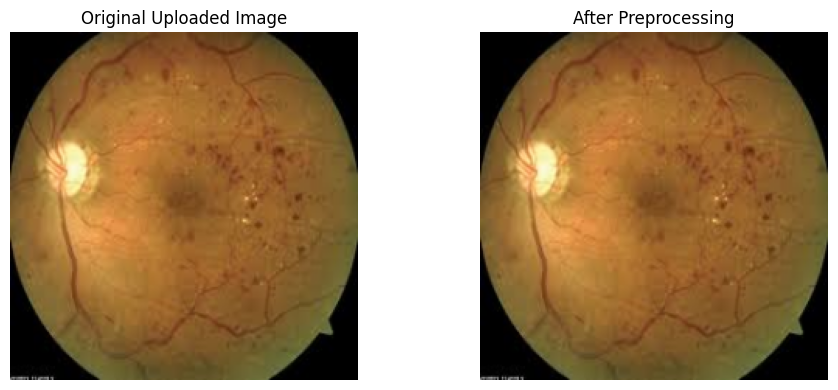

In [ ]:
# Cell 6: Patient details + Image selection (Folder OR Upload)
import tkinter as tk
from tkinter import filedialog
from IPython.display import clear_output

IMG_FOLDER       = os.path.join(PROJECT_DIR, 'data', 'processed', 'train_images')
available_images = sorted(os.listdir(IMG_FOLDER))[:]

# Reset image variables
img_norm    = None
img_display = None
IMAGE_PATH  = None

# Patient Info Widgets
name_widget = widgets.Text(
    description='Patient Name:',
    placeholder='e.g. Ramesh Kumar',
    layout=widgets.Layout(width='400px')
)
age_widget = widgets.IntText(
    description='Age:',
    value=45,
    layout=widgets.Layout(width='200px')
)
eye_widget = widgets.Dropdown(
    description='Eye Side:',
    options=['Left Eye', 'Right Eye', 'Both'],
    layout=widgets.Layout(width='250px')
)
notes_widget = widgets.Text(
    description='Notes:',
    placeholder='Optional clinical notes',
    layout=widgets.Layout(width='400px')
)

# Image Source Toggle
source_widget = widgets.ToggleButtons(
    options=['Select from folder', 'Upload raw image'],
    description='Image:',
    button_style='info',
    layout=widgets.Layout(width='500px')
)

# Dropdown for preprocessed folder
image_widget = widgets.Dropdown(
    description='Select Image:',
    options=available_images,
    layout=widgets.Layout(width='500px')
)

# Upload Button
upload_btn = widgets.Button(
    description='Browse Image',
    button_style='primary',
    icon='upload',
    layout=widgets.Layout(width='200px')
)
upload_status = widgets.Label(value='No image selected yet.')
upload_box    = widgets.VBox([upload_btn, upload_status])
upload_box.layout.display = 'none'

# Browse local file using tkinter
def on_upload_clicked(b):
    global img_norm, img_display, IMAGE_PATH
    try:
        # Close all previous figures first
        plt.close('all')

        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        filepath = filedialog.askopenfilename(
            title='Select Retinal Image',
            filetypes=[('Image files', '*.png *.jpg *.jpeg *.bmp')]
        )
        root.destroy()

        if filepath:
            # Read and preprocess image
            img_raw     = cv2.imread(filepath)
            img_raw     = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_raw, (224, 224))
            img_norm    = img_resized.astype(np.float32) / 255.0
            img_display = img_resized
            IMAGE_PATH  = filepath

            # Validate that image is a retinal fundus image
            is_valid, val_conf, val_reason = validate_image(filepath)
            if not is_valid:
                upload_status.value = f'WARNING: {val_reason}'
            else:
                upload_status.value = f'Ready: {os.path.basename(filepath)} (retinal check: {val_conf:.0%})'

            # Clear previous output
            clear_output(wait=True)

            # Redisplay widgets
            print('Fill in patient details and select image:')
            print('='*50)
            display(name_widget, age_widget, eye_widget, notes_widget)
            print()
            display(source_widget)
            display(upload_box)
            print('\nAfter filling details run Cell 7 to get prediction!')

            # Show only current image
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            axes[0].imshow(img_resized)
            axes[0].set_title('Original Uploaded Image')
            axes[0].axis('off')
            axes[1].imshow(img_norm)
            axes[1].set_title('After Preprocessing')
            axes[1].axis('off')
            plt.tight_layout()
            plt.show()

        else:
            upload_status.value = 'No file selected.'

    except Exception as e:
        upload_status.value = f'Error: {str(e)}'

upload_btn.on_click(on_upload_clicked)

# Toggle between folder and upload
def on_source_change(change):
    global img_norm, img_display, IMAGE_PATH
    if change['new'] == 'Select from folder':
        image_widget.layout.display = ''
        upload_box.layout.display   = 'none'
        img_norm    = None
        img_display = None
        IMAGE_PATH  = None
        upload_status.value = 'No image selected yet.'
    else:
        image_widget.layout.display = 'none'
        upload_box.layout.display   = ''

source_widget.observe(on_source_change, names='value')

# Display everything
print('Fill in patient details and select image:')
print('='*50)
display(name_widget, age_widget, eye_widget, notes_widget)
print()
display(source_widget)
display(image_widget)
display(upload_box)
print('\nAfter filling details run Cell 7 to get prediction!')

In [21]:
# Cell 7: Run ensemble prediction using widget inputs
PATIENT_NAME = name_widget.value.strip()
PATIENT_AGE  = age_widget.value
EYE_SIDE     = eye_widget.value
NOTES        = notes_widget.value.strip()

# Auto detect which image source was used
if img_norm is not None and img_display is not None:
    # User browsed and uploaded a raw image in Cell 6 — already preprocessed
    print(f'Using uploaded image : {os.path.basename(IMAGE_PATH)}')
else:
    # User selected from preprocessed folder dropdown
    IMAGE_PATH  = os.path.join(IMG_FOLDER, image_widget.value)
    img_norm, img_display = preprocess_image(IMAGE_PATH, IMG_SIZE)
    print(f'Using folder image   : {image_widget.value}')

if not PATIENT_NAME:
    print('Please enter patient name first!')
elif img_norm is None:
    print('No image found. Select from folder or browse in Cell 6!')
else:
    # ── Validate uploaded images (skip for preprocessed folder images) ──
    is_from_folder = (IMAGE_PATH.startswith(IMG_FOLDER))
    run_prediction = True

    if not is_from_folder:
        # User uploaded a raw image — validate it first
        is_valid, val_conf, val_reason = validate_image(IMAGE_PATH)
        if not is_valid:
            print('=' * 55)
            print('  ⚠️  IMAGE VALIDATION FAILED')
            print('=' * 55)
            print(f'  {val_reason}')
            print()
            print('  The uploaded image does not appear to be a retinal')
            print('  fundus photograph. Please upload a valid retinal scan.')
            print('  DR grading will NOT be performed on this image.')
            print('=' * 55)
            run_prediction = False
        else:
            print(f'  ✅ Retinal image check passed (confidence: {val_conf:.0%})')
    else:
        print('  ✅ Using verified image from processed dataset folder')

    if run_prediction:
        img_array = np.expand_dims(img_norm, axis=0)

        probs, pred_grade, confidence, eff_probs, res_probs = ensemble_predict(img_array)

        print('=' * 55)
        print('  ENSEMBLE PREDICTION RESULT')
        print('=' * 55)
        print(f'  Patient     : {PATIENT_NAME}')
        print(f'  Age         : {PATIENT_AGE}')
        print(f'  Eye         : {EYE_SIDE}')
        print(f'  Image       : {os.path.basename(IMAGE_PATH)}')
        print(f'  Grade       : {pred_grade} - {GRADE_NAMES[pred_grade]}')
        print(f'  Confidence  : {confidence*100:.2f}%')
        print(f'  Advice      : {GRADE_ADVICE[pred_grade]}')
        print('=' * 55)
        print(f'\n  EfficientNet : Grade {np.argmax(eff_probs)} - {GRADE_NAMES[np.argmax(eff_probs)]} ({eff_probs.max()*100:.1f}%)')
        print(f'  ResNet50     : Grade {np.argmax(res_probs)} - {GRADE_NAMES[np.argmax(res_probs)]} ({res_probs.max()*100:.1f}%)')
        print(f'  Ensemble     : Grade {pred_grade} - {GRADE_NAMES[pred_grade]} ({confidence*100:.1f}%)')
        print('\nAll Grade Probabilities (Ensemble):')
        for i, (name, prob) in enumerate(zip(GRADE_NAMES, probs)):
            bar   = '#' * int(prob * 30)
            arrow = ' <-- predicted' if i == pred_grade else ''
            print(f'  Grade {i} {name:<18} {bar:<30} {prob*100:.1f}%{arrow}')

Using uploaded image : Test1.jpg
  ENSEMBLE PREDICTION RESULT
  Patient     : KR
  Age         : 45
  Eye         : Left Eye
  Image       : Test1.jpg
  Grade       : 3 - Severe DR
  Confidence  : 36.14%
  Advice      : Severe DR detected. Urgent ophthalmology referral recommended.

  EfficientNet : Grade 2 - Moderate DR (46.3%)
  ResNet50     : Grade 3 - Severe DR (64.0%)
  Ensemble     : Grade 3 - Severe DR (36.1%)

All Grade Probabilities (Ensemble):
  Grade 0 No DR                                             2.6%
  Grade 1 Mild DR            ###                            10.5%
  Grade 2 Moderate DR        ########                       27.5%
  Grade 3 Severe DR          ##########                     36.1% <-- predicted
  Grade 4 Proliferative DR   ######                         23.3%


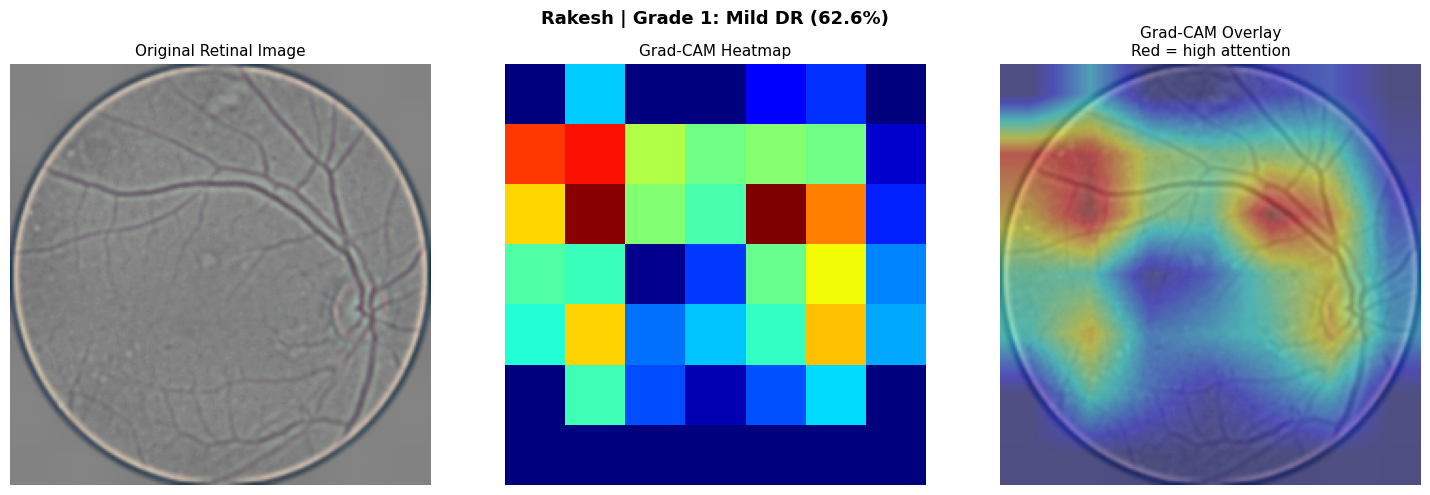

Grad-CAM visualization saved!


In [8]:
# Cell 8: Visualize prediction + Grad-CAM heatmap
import tensorflow as tf

def get_gradcam(model, img_array):
    try:
        base       = model.get_layer('efficientnetb3')
        conv_layer = base.get_layer('top_conv')

        # Build flat model connecting input directly to conv layer
        flat_model = keras.models.Model(
            inputs  = base.input,
            outputs = [conv_layer.output, base.get_layer('top_activation').output]
        )

        img_tensor = tf.cast(img_array, tf.float32)

        with tf.GradientTape() as tape:
            tape.watch(img_tensor)
            conv_outputs, activated = flat_model(img_tensor, training=False)
            tape.watch(conv_outputs)

            # Run remaining layers manually
            x = activated
            for layer in model.layers:
                if layer.name == 'efficientnetb3':
                    continue
                try:
                    x = layer(x, training=False)
                except:
                    continue

            predictions = x
            class_score = predictions[:, pred_grade]

        grads = tape.gradient(class_score, conv_outputs)

        if grads is None:
            # Fallback to input gradient saliency map
            with tf.GradientTape() as tape2:
                tape2.watch(img_tensor)
                preds       = model(img_tensor, training=False)
                class_score = preds[:, pred_grade]
            grads   = tape2.gradient(class_score, img_tensor)
            grads   = tf.abs(grads)
            heatmap = tf.reduce_max(grads, axis=-1)[0]
            heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
            return heatmap.numpy()

        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
        heatmap      = tf.squeeze(heatmap)
        heatmap      = tf.maximum(heatmap, 0)
        heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
        return heatmap.numpy()

    except Exception as e:
        print(f'Grad-CAM error: {e}')
        return None


def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    img_uint8       = np.uint8(255 * img) if img.max() <= 1.0 else np.uint8(img)
    return cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)


# Generate Grad-CAM using EfficientNet
heatmap = get_gradcam(efficientnet_model, img_array)

if heatmap is not None:
    overlay = overlay_heatmap(img_norm, heatmap)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f'{PATIENT_NAME} | Grade {pred_grade}: {GRADE_NAMES[pred_grade]} ({confidence*100:.1f}%)',
        fontsize=13, fontweight='bold'
    )

    axes[0].imshow(img_display)
    axes[0].set_title('Original Retinal Image', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=11)
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Grad-CAM Overlay\nRed = high attention', fontsize=11)
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(
        os.path.join(PROJECT_DIR, 'models', 'prediction_gradcam.png'),
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print('Grad-CAM visualization saved!')
else:
    print('Grad-CAM failed - showing original image only')
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img_display)
    ax.set_title(
        f'{PATIENT_NAME} | {EYE_SIDE}\nGrade {pred_grade}: {GRADE_NAMES[pred_grade]} ({confidence*100:.1f}%)',
        fontsize=11, fontweight='bold'
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 9: Save ensemble prediction result to MySQL database
auto_notes = NOTES if NOTES else (
    f'Ensemble prediction (EfficientNetB3 + ResNet50). '
    f'EfficientNet: Grade {np.argmax(eff_probs)} ({eff_probs.max()*100:.1f}%), '
    f'ResNet50: Grade {np.argmax(res_probs)} ({res_probs.max()*100:.1f}%). '
    f'Scan date: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}'
)

record_id = insert_scan(
    patient_name = PATIENT_NAME,
    patient_age  = PATIENT_AGE,
    eye_side     = EYE_SIDE,
    grade        = pred_grade,
    confidence   = confidence,
    notes        = auto_notes
)

if record_id:
    print('Prediction saved to MySQL database!')
    print(f'  Record ID  : {record_id}')
    print(f'  Patient    : {PATIENT_NAME}')
    print(f'  Grade      : {GRADE_NAMES[pred_grade]}')
    print(f'  Confidence : {confidence*100:.2f}%')
    print(f'  Saved at   : {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
else:
    print('Failed to save. Check MySQL connection in src/database.py')

Record inserted! ID: 24 | Patient: Assem Kelkar | Grade: Moderate DR
Prediction saved to MySQL database!
  Record ID  : 24
  Patient    : Assem Kelkar
  Grade      : Moderate DR
  Confidence : 47.14%
  Saved at   : 2026-03-23 11:04:34


In [ ]:
# Cell 10: View all records in database
print('Current database records:')
print_all_scans()

Current database records:

ID    Name                 Age   Eye          Grade                Confidence   Date
24    Assem Kelkar         45    Left Eye     Moderate DR          47.1       % 2026-03-23 11:04:34
23    Rakesh Kumar         46    Both         Severe DR            81.1       % 2026-03-21 01:33:51
22    Rakesh Kumar         46    Both         Moderate DR          42.6       % 2026-03-21 01:29:42
20    Anil Verma           60    Both         Moderate DR          51.8       % 2026-03-21 01:06:35
21    Sunita Patil         48    Left Eye     Mild DR              79.3       % 2026-03-21 01:06:35
19    Priya Sharma         52    Right Eye    Moderate DR          47.1       % 2026-03-21 01:06:34
18    Ronak Patel          55    Right Eye    No DR                82.6       % 2026-03-21 01:05:09
17    Ramesh Kumar         45    Left Eye     Moderate DR          47.1       % 2026-03-21 00:20:55
16    Jeet Paghdar         50    Left Eye     No DR                91.0       % 2026-03-

In [ ]:
# Cell 11: Database statistics
stats = get_stats()
print('=' * 40)
print('  DATABASE STATISTICS')
print('=' * 40)
print(f'  Total scans    : {stats["total"]}')
print(f'  DR detected    : {stats["dr_detected"]}')
print(f'  Severe cases   : {stats["severe"]}')
print(f'  Avg confidence : {stats["avg_conf"]*100:.1f}%')
print('=' * 40)

  DATABASE STATISTICS
  Total scans    : 9
  DR detected    : 7
  Severe cases   : 1
  Avg confidence : 63.3%


In [ ]:
# Cell 12: Final database view
print('Final database state:')
print_all_scans()

stats = get_stats()
print('Summary:')
print(f'  Total patients scanned : {stats["total"]}')
print(f'  DR detected            : {stats["dr_detected"]}')
print(f'  Severe / Proliferative : {stats["severe"]}')
print(f'  Average confidence     : {stats["avg_conf"]*100:.1f}%')
print('\nOpen MySQL Workbench to verify records visually!')

Final database state:

ID    Name                 Age   Eye          Grade                Confidence   Date
24    Assem Kelkar         45    Left Eye     Moderate DR          47.1       % 2026-03-23 11:04:34
23    Rakesh Kumar         46    Both         Severe DR            81.1       % 2026-03-21 01:33:51
22    Rakesh Kumar         46    Both         Moderate DR          42.6       % 2026-03-21 01:29:42
20    Anil Verma           60    Both         Moderate DR          51.8       % 2026-03-21 01:06:35
21    Sunita Patil         48    Left Eye     Mild DR              79.3       % 2026-03-21 01:06:35
19    Priya Sharma         52    Right Eye    Moderate DR          47.1       % 2026-03-21 01:06:34
18    Ronak Patel          55    Right Eye    No DR                82.6       % 2026-03-21 01:05:09
17    Ramesh Kumar         45    Left Eye     Moderate DR          47.1       % 2026-03-21 00:20:55
16    Jeet Paghdar         50    Left Eye     No DR                91.0       % 2026-03-20 2